# India AQI Dataset - Practical-7

Preprocessing, classification, and clustering on the Kaggle AQI dataset.

**Data Analytics (IT 202B)**  
**Name:** Ojasv Singh  
**University Roll No.:** 202401100500120  
**CSIT - B**

In [20]:
from pathlib import Path
import re
import warnings

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.cluster import AgglomerativeClustering, KMeans
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    f1_score,
    precision_score,
    recall_score,
    silhouette_score,
)
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import GaussianNB
from sklearn.neighbors import KNeighborsClassifier
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.tree import DecisionTreeClassifier
from sklearn.decomposition import PCA

warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid", palette="Set2")
pd.set_option("display.max_columns", None)
pd.set_option("display.width", 120)


def standardize_column_names(frame: pd.DataFrame) -> pd.DataFrame:
    renamed = frame.copy()
    renamed.columns = (
        renamed.columns.astype(str)
        .str.strip()
        .str.lower()
        .str.replace(r"[^0-9a-zA-Z]+", "_", regex=True)
        .str.replace(r"_+", "_", regex=True)
        .str.strip("_")
    )
    return renamed


def find_first_existing_column(frame: pd.DataFrame, candidates: list[str]) -> str | None:
    lookup = {column.lower(): column for column in frame.columns}
    for candidate in candidates:
        if candidate.lower() in lookup:
            return lookup[candidate.lower()]
    return None


def pick_keyword_column(frame: pd.DataFrame, keywords: list[str]) -> str | None:
    for column in frame.columns:
        lower_column = column.lower()
        if any(keyword in lower_column for keyword in keywords):
            return column
    return None


def safe_parse_datetime(series: pd.Series) -> pd.Series:
    parsed = pd.to_datetime(series, errors="coerce", infer_datetime_format=True)
    if parsed.notna().mean() >= 0.4:
        return parsed
    return pd.Series(pd.NaT, index=series.index)


In [21]:
# Dataset discovery and preprocessing helpers
import kagglehub
import os

# Download latest version
path = kagglehub.dataset_download("saikiranudayana/india-air-quality-index-aqi-dataset-20232025")

print("Path to dataset files:", path)

csv_path = os.path.join(path, "aqi.csv")
DATASET_PATH = Path(csv_path)


def locate_dataset() -> Path:
    dataset_file = Path(DATASET_PATH)
    if dataset_file.is_file():
        return dataset_file
    raise FileNotFoundError(f"Expected AQI CSV not found at: {dataset_file}")


def load_aqi_dataset() -> pd.DataFrame:
    dataset_file = locate_dataset()
    frame = pd.read_csv(dataset_file)
    frame = standardize_column_names(frame)
    print(f"Loaded dataset: {dataset_file}")
    print(f"Shape: {frame.shape[0]:,} rows x {frame.shape[1]:,} columns")
    return frame


def coerce_numeric_like_columns(frame: pd.DataFrame, threshold: float = 0.7) -> pd.DataFrame:
    updated = frame.copy()
    object_columns = updated.select_dtypes(include=["object"]).columns

    for column in object_columns:
        stripped = updated[column].astype(str).str.replace(",", "", regex=False).str.strip()
        converted = pd.to_numeric(stripped, errors="coerce")
        if converted.notna().mean() >= threshold:
            updated[column] = converted

    return updated


def expand_datetime_columns(frame: pd.DataFrame) -> pd.DataFrame:
    updated = frame.copy()
    datetime_columns = []

    for column in list(updated.columns):
        if any(keyword in column.lower() for keyword in ["date", "time", "timestamp", "datetime"]):
            parsed = safe_parse_datetime(updated[column])
            if parsed.notna().mean() >= 0.4:
                updated[column] = parsed
                datetime_columns.append(column)

    for column in datetime_columns:
        updated[f"{column}_year"] = updated[column].dt.year
        updated[f"{column}_month"] = updated[column].dt.month
        updated[f"{column}_day"] = updated[column].dt.day
        updated[f"{column}_dayofweek"] = updated[column].dt.dayofweek
        updated[f"{column}_hour"] = updated[column].dt.hour
        updated.drop(columns=[column], inplace=True)

    return updated


def clip_outliers_iqr(frame: pd.DataFrame) -> pd.DataFrame:
    updated = frame.copy()
    numeric_columns = updated.select_dtypes(include=[np.number]).columns

    for column in numeric_columns:
        q1 = updated[column].quantile(0.25)
        q3 = updated[column].quantile(0.75)
        iqr = q3 - q1
        if pd.isna(iqr) or iqr == 0:
            continue
        lower_bound = q1 - 1.5 * iqr
        upper_bound = q3 + 1.5 * iqr
        updated[column] = updated[column].clip(lower_bound, upper_bound)

    return updated


def derive_target_column(frame: pd.DataFrame) -> tuple[str, pd.Series | None]:
    target_candidates = [
        "air_quality_status",
        "aqi_bucket",
        "aqi_category",
        "air_quality_category",
        "category",
        "pollution_category",
        "pollution_level",
        "level",
        "status",
        "class",
        "label",
    ]
    existing_target = find_first_existing_column(frame, target_candidates)
    aqi_column = pick_keyword_column(frame, ["aqi", "air_quality_index"])

    if existing_target is not None:
        return existing_target, None

    if aqi_column is None:
        raise ValueError("No suitable target column found and no AQI numeric column was detected.")

    numeric_aqi = pd.to_numeric(frame[aqi_column], errors="coerce")
    frame[aqi_column] = numeric_aqi
    derived_target = pd.cut(
        numeric_aqi,
        bins=[-np.inf, 50, 100, 200, 300, 400, np.inf],
        labels=["Good", "Satisfactory", "Moderate", "Poor", "Very Poor", "Severe"],
        include_lowest=True,
    )
    frame["aqi_category"] = derived_target.astype("string")
    return "aqi_category", frame["aqi_category"]


def prepare_model_frame(frame: pd.DataFrame) -> tuple[pd.DataFrame, str]:
    prepared = frame.copy().drop_duplicates().reset_index(drop=True)
    prepared = prepared.dropna(axis=1, how="all")
    prepared = coerce_numeric_like_columns(prepared)
    prepared = expand_datetime_columns(prepared)

    target_column, target_series = derive_target_column(prepared)
    if target_series is not None:
        prepared[target_column] = target_series.astype("string")

    categorical_columns = [
        column for column in prepared.select_dtypes(include=["object", "category", "string"]).columns
        if column != target_column
    ]

    for column in categorical_columns:
        prepared[column] = prepared[column].astype("string").fillna("missing").replace({"<NA>": "missing"})

    numeric_columns = prepared.select_dtypes(include=[np.number]).columns
    for column in numeric_columns:
        if prepared[column].isna().any():
            prepared[column] = prepared[column].fillna(prepared[column].median())

    prepared = clip_outliers_iqr(prepared)

    label_encoders = {}
    for column in categorical_columns:
        encoder = LabelEncoder()
        prepared[column] = encoder.fit_transform(prepared[column].astype(str))
        label_encoders[column] = encoder

    if target_column in prepared.columns and prepared[target_column].dtype == object:
        prepared[target_column] = prepared[target_column].astype(str)

    return prepared, target_column

Path to dataset files: C:\Users\OJASV\.cache\kagglehub\datasets\saikiranudayana\india-air-quality-index-aqi-dataset-20232025\versions\1


In [22]:
# Load the AQI data and prepare the cleaned modeling frame

raw_df = load_aqi_dataset()
display(raw_df.head())
print("Missing values before preprocessing:")
print(raw_df.isna().sum().sort_values(ascending=False).head(10))

model_df, target_column = prepare_model_frame(raw_df)
print(f"\nTarget column selected for classification: {target_column}")
print(f"Processed frame shape: {model_df.shape[0]:,} rows x {model_df.shape[1]:,} columns")
display(model_df.head())

cluster_base = coerce_numeric_like_columns(raw_df.copy().drop_duplicates().reset_index(drop=True))
cluster_base = expand_datetime_columns(cluster_base)
print(f"Cluster base shape: {cluster_base.shape[0]:,} rows x {cluster_base.shape[1]:,} columns")

Loaded dataset: C:\Users\OJASV\.cache\kagglehub\datasets\saikiranudayana\india-air-quality-index-aqi-dataset-20232025\versions\1\aqi.csv
Shape: 235,785 rows x 9 columns


,date,state,area,number_of_monitoring_stations,prominent_pollutants,aqi_value,air_quality_status,unit,note
0,30-04-2025,Maharashtra,Amravati,2,PM10,78,Satisfactory,number_of_monitoring_stations in Absolute Numb...,NaN
1,30-04-2025,Bihar,Purnia,1,CO,56,Satisfactory,number_of_monitoring_stations in Absolute Numb...,NaN
2,30-04-2025,Madhya Pradesh,Katni,1,O3,98,Satisfactory,number_of_monitoring_stations in Absolute Numb...,NaN
3,30-04-2025,Chhattisgarh,Tumidih,1,PM10,103,Moderate,number_of_monitoring_stations in Absolute Numb...,NaN
4,30-04-2025,Assam,Byrnihat,1,PM2.5,61,Satisfactory,number_of_monitoring_stations in Absolute Numb...,NaN


Missing values before preprocessing:
note                             235785
date                                  0
state                                 0
area                                  0
number_of_monitoring_stations         0
prominent_pollutants                  0
aqi_value                             0
air_quality_status                    0
unit                                  0
dtype: int64

Target column selected for classification: air_quality_status
Processed frame shape: 235,785 rows x 12 columns


,state,area,number_of_monitoring_stations,prominent_pollutants,aqi_value,air_quality_status,unit,date_year,date_month,date_day,date_dayofweek,date_hour
0,16,10,2,16,78.0,Satisfactory,0,2025,4,30,2,0
1,4,220,1,0,56.0,Satisfactory,0,2025,4,30,2,0
2,15,147,1,13,98.0,Satisfactory,0,2025,4,30,2,0
3,6,274,1,16,103.0,Moderate,0,2025,4,30,2,0
4,3,60,1,32,61.0,Satisfactory,0,2025,4,30,2,0


Cluster base shape: 235,785 rows x 13 columns


,Model,Accuracy,Precision,Recall,F1 Score
0,Decision Tree,0.980813,0.981067,0.980813,0.980935
2,Naive Bayes,0.921336,0.929442,0.921336,0.922682
1,KNN,0.842045,0.841075,0.842045,0.840954


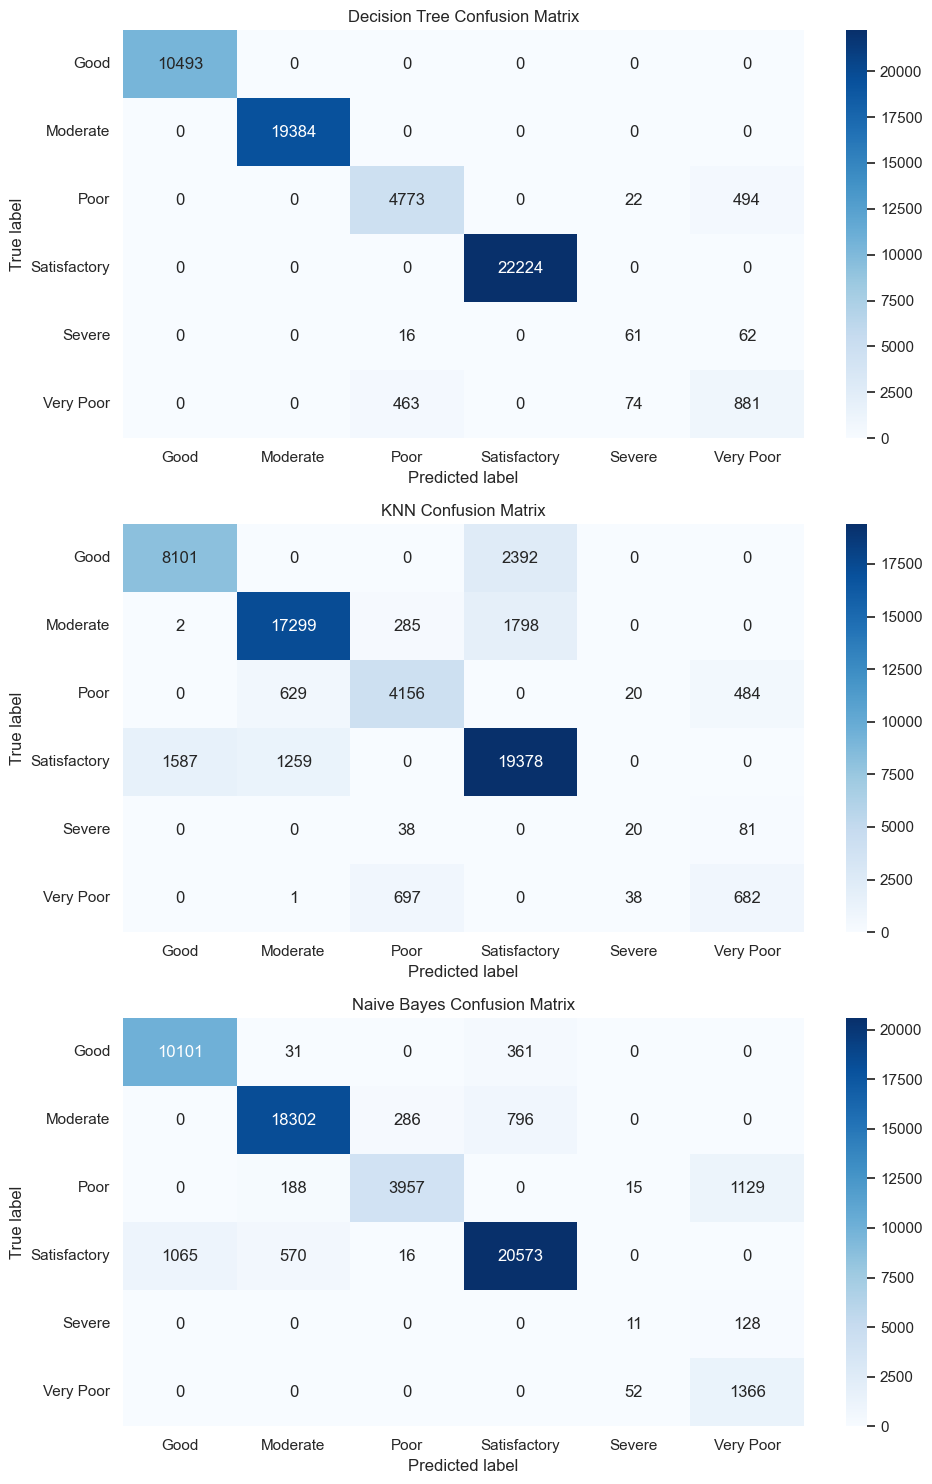

In [23]:
# Classification: Decision Tree, KNN, and Naive Bayes

classification_df = model_df.copy()
X = classification_df.drop(columns=[target_column])
y_raw = classification_df[target_column].astype(str)

target_encoder = LabelEncoder()
y = target_encoder.fit_transform(y_raw)
class_names = list(target_encoder.classes_)

X = X.replace([np.inf, -np.inf], np.nan)
X = X.fillna(X.median(numeric_only=True))

if len(np.unique(y)) < 2:
    raise ValueError("Classification requires at least two classes.")

class_counts = np.bincount(y)
stratify_target = y if class_counts.min() >= 2 else None

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.25,
    random_state=42,
    stratify=stratify_target,
)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

models = {
    "Decision Tree": DecisionTreeClassifier(random_state=42),
    "KNN": KNeighborsClassifier(n_neighbors=5),
    "Naive Bayes": GaussianNB(),
}

results = []
fig, axes = plt.subplots(len(models), 1, figsize=(10, 5 * len(models)))
axes = np.atleast_1d(axes)

for axis, (model_name, model) in zip(axes, models.items()):
    model.fit(X_train_scaled, y_train)
    predictions = model.predict(X_test_scaled)

    accuracy = accuracy_score(y_test, predictions)
    precision = precision_score(y_test, predictions, average="weighted", zero_division=0)
    recall = recall_score(y_test, predictions, average="weighted", zero_division=0)
    f1 = f1_score(y_test, predictions, average="weighted", zero_division=0)

    results.append(
        {
            "Model": model_name,
            "Accuracy": accuracy,
            "Precision": precision,
            "Recall": recall,
            "F1 Score": f1,
        }
    )

    cm = confusion_matrix(y_test, predictions, labels=np.arange(len(class_names)))
    sns.heatmap(
        cm,
        annot=True,
        fmt="d",
        cmap="Blues",
        xticklabels=class_names,
        yticklabels=class_names,
        ax=axis,
    )
    axis.set_title(f"{model_name} Confusion Matrix")
    axis.set_xlabel("Predicted label")
    axis.set_ylabel("True label")

plt.tight_layout()
results_df = pd.DataFrame(results).sort_values(by="F1 Score", ascending=False)
display(results_df)

Clustering by grouped 'state' values.
Chosen number of clusters: 2


,state,kmeans_cluster,hierarchical_cluster
0,Andaman and Nicobar Islands,1,1
1,Andhra Pradesh,0,0
2,Arunachal Pradesh,0,0
3,Assam,0,0
4,Bihar,0,0
5,Chandigarh,0,0
6,Chhattisgarh,0,0
7,Delhi,0,0
8,Gujarat,0,0
9,Haryana,0,0


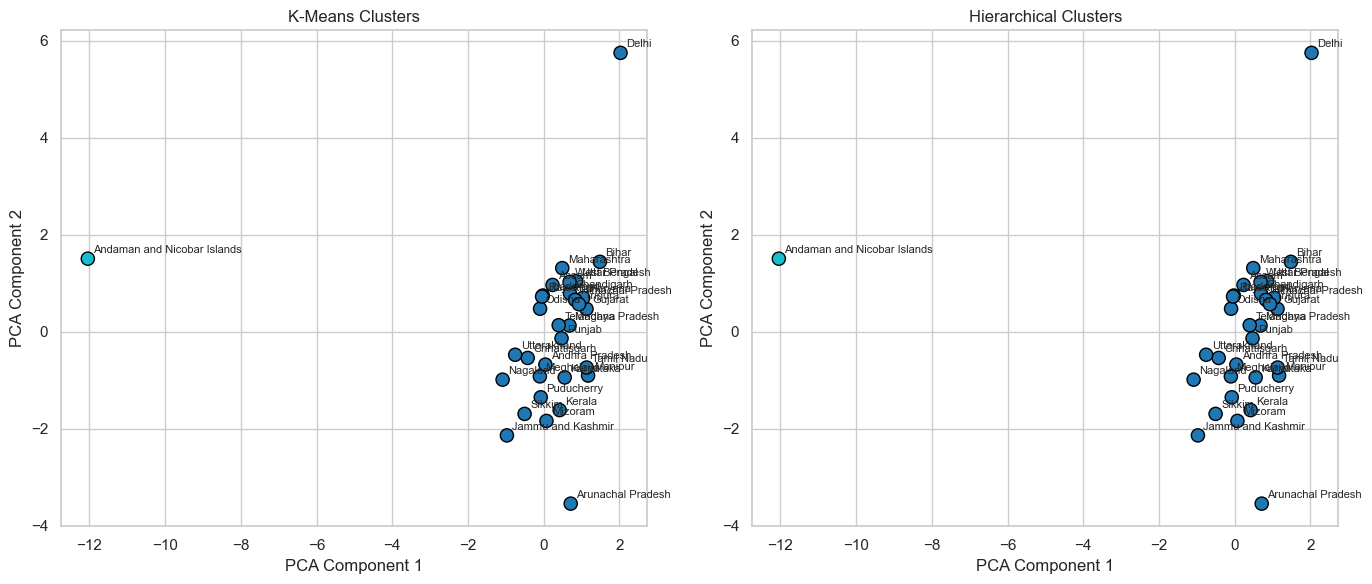

In [24]:
# Clustering: K-Means and Hierarchical Clustering

cluster_group_column = find_first_existing_column(cluster_base, ["state", "area", "city", "station", "site", "location", "monitoring_station"])
cluster_source = cluster_base.copy()

if cluster_group_column is not None:
    cluster_numeric_columns = cluster_source.select_dtypes(include=[np.number]).columns.tolist()
    cluster_data = cluster_source.groupby(cluster_group_column)[cluster_numeric_columns].agg(["mean", "std"])
    cluster_data.columns = [f"{column}_{stat}" for column, stat in cluster_data.columns]
    cluster_data = cluster_data.replace([np.inf, -np.inf], np.nan)
    cluster_data = cluster_data.fillna(0)
    cluster_labels = cluster_data.index.astype(str)
    print(f"Clustering by grouped '{cluster_group_column}' values.")
else:
    cluster_data = cluster_source.select_dtypes(include=[np.number]).copy()
    cluster_data = cluster_data.replace([np.inf, -np.inf], np.nan)
    cluster_data = cluster_data.fillna(cluster_data.median(numeric_only=True)).fillna(0)
    cluster_labels = cluster_data.index.astype(str)
    print("Clustering individual records because no grouping column was found.")

if cluster_data.shape[0] < 3:
    raise ValueError("Clustering requires at least 3 samples.")

cluster_scaler = StandardScaler()
cluster_scaled = cluster_scaler.fit_transform(cluster_data)

max_k = min(6, cluster_scaled.shape[0] - 1)
silhouette_scores = {}
for k in range(2, max_k + 1):
    candidate_model = KMeans(n_clusters=k, random_state=42, n_init=10)
    candidate_labels = candidate_model.fit_predict(cluster_scaled)
    if len(np.unique(candidate_labels)) > 1:
        silhouette_scores[k] = silhouette_score(cluster_scaled, candidate_labels)

best_k = max(silhouette_scores, key=silhouette_scores.get) if silhouette_scores else 2
print(f"Chosen number of clusters: {best_k}")

kmeans_model = KMeans(n_clusters=best_k, random_state=42, n_init=10)
kmeans_labels = kmeans_model.fit_predict(cluster_scaled)

hierarchical_model = AgglomerativeClustering(n_clusters=best_k)
hierarchical_labels = hierarchical_model.fit_predict(cluster_scaled)

cluster_results = pd.DataFrame(
    {
        cluster_group_column if cluster_group_column is not None else "record": cluster_labels,
        "kmeans_cluster": kmeans_labels,
        "hierarchical_cluster": hierarchical_labels,
    }
)
display(cluster_results)

pca = PCA(n_components=2, random_state=42)
cluster_2d = pca.fit_transform(cluster_scaled)

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
for axis, labels, title in [
    (axes[0], kmeans_labels, "K-Means Clusters"),
    (axes[1], hierarchical_labels, "Hierarchical Clusters"),
]:
    axis.scatter(cluster_2d[:, 0], cluster_2d[:, 1], c=labels, cmap="tab10", s=90, edgecolor="black")
    for index, name in enumerate(cluster_labels):
        axis.annotate(name, (cluster_2d[index, 0], cluster_2d[index, 1]), textcoords="offset points", xytext=(4, 4), fontsize=8)
    axis.set_title(title)
    axis.set_xlabel("PCA Component 1")
    axis.set_ylabel("PCA Component 2")
plt.tight_layout()